This is the selfish elite model shown in the mathematical appendix A in Peter Turchin's Historical Dynamics.

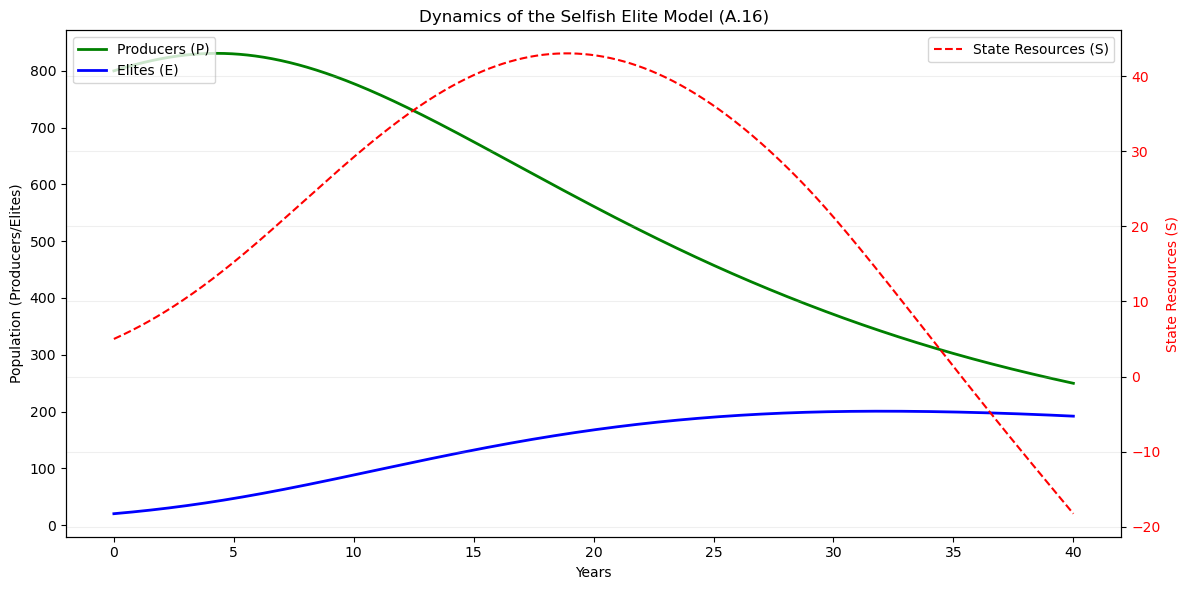

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def selfish_elite_model(t, y, beta1, rho0, g0, a, delta1, beta2, delta2, gamma, alpha, h, c):
    P, E, S = y
    g_S = g0 * (h + S) / (h + (1 + c) * S)
    dPdt = (beta1 * rho0 * (1 - g_S * P) * P) / (1 + a * E) - delta1 * P
    dEdt = (beta2 * rho0 * a * E * (1 - g_S * P) * P) / (1 + a * E) - delta2 * E
    revenue = gamma * max(0, dEdt)
    expenditure = alpha * E
    dSdt = revenue - expenditure
    return [dPdt, dEdt, dSdt]

params = {
    'beta1': 0.2,
    'rho0': 1.0,
    'g0': 0.001,
    'a': 0.01,
    'delta1': 0.1,
    'beta2': 0.05,
    'delta2': 0.05,
    'gamma': 0.5,
    'alpha': 0.02,
    'h': 1.0,
    'c': 2.0
}

# Initial Conditions
y0 = [800, 20, 5]

# Define time span and evaluation points
t_span = (0, 40)  # 500 years
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Unpack params in the correct order for the function
solution = solve_ivp(
    selfish_elite_model, 
    t_span, 
    y0, 
    t_eval=t_eval,
    args=(
        params['beta1'], 
        params['rho0'], 
        params['g0'], 
        params['a'], 
        params['delta1'], 
        params['beta2'], 
        params['delta2'], 
        params['gamma'], 
        params['alpha'], 
        params['h'], 
        params['c']
    )
)

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Years')
ax1.set_ylabel('Population (Producers/Elites)', color='black')
ax1.plot(solution.t, solution.y[0], label='Producers (P)', color='green', linewidth=2)
ax1.plot(solution.t, solution.y[1], label='Elites (E)', color='blue', linewidth=2)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.set_ylabel('State Resources (S)', color='red')
ax2.plot(solution.t, solution.y[2], label='State Resources (S)', color='red', linestyle='--')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Dynamics of the Selfish Elite Model (A.16)")
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.show()

However, due to how the integrate function works in Scipy, the state resources hitting 0 causes the program to end. This is unsurprising, as this is the point where state collapse occurs. I have tried adding a reset function. However, it becomes clear that this model does not work well for tracking cycles between populations. 

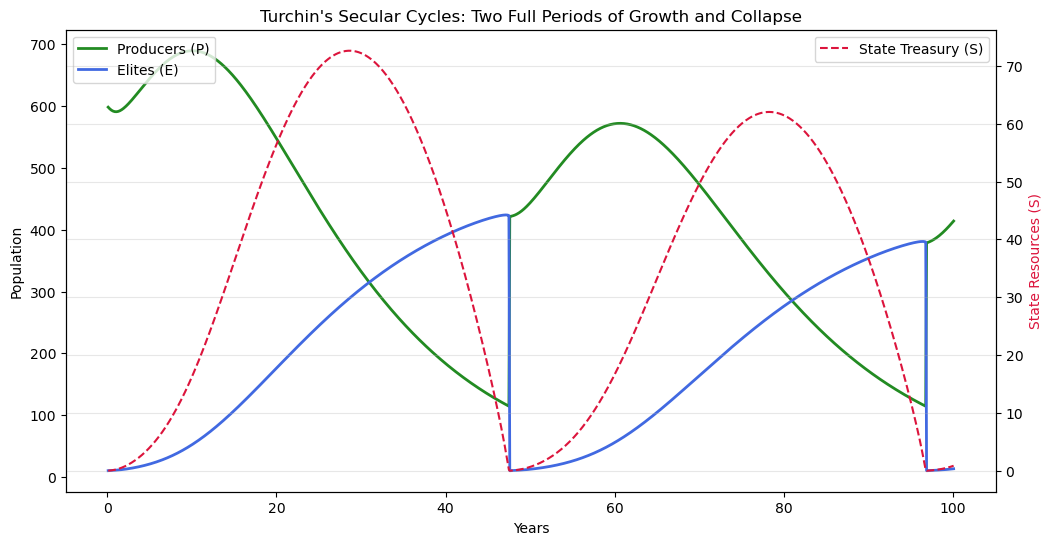

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def simulate_two_cycles(params, total_years, dt):
    # Initial Conditions (A new dynasty starts)
    P, E, S = 600.0, 10.0, 0
    
    # Store history for plotting
    history = {'t': [], 'P': [], 'E': [], 'S': []}
    
    # Extract params for readability
    b1, d1 = params['beta1'], params['delta1']
    b2, d2 = params['beta2'], params['delta2']
    rho0, g0, a = params['rho0'], params['g0'], params['a']
    gamma, alpha, h, c = params['gamma'], params['alpha'], params['h'], params['c']

    t = 0
    while t < total_years:
        # 1. State-Dependent Carrying Capacity (g_S)
        g_S = g0 * (h + S) / (h + (1 + c) * S)
        
        # 2. Producer Growth
        dPdt = (b1 * rho0 * (1 - g_S * P) * P) / (1 + a * E) - d1 * P
        
        # 3. Elite Growth & Mortality (Dynamic delta2)
        # If S is high, elites live longer. If S is 0, they fight (higher death).
        growth_e = (b2 * rho0 * a * E * (1 - g_S * P) * P) / (1 + a * E)
        dynamic_d2 = d2 / (1 + (S / h))
        dEdt = growth_e - dynamic_d2 * E
        
        # 4. State Resources (Revenue - Expenditure)
        revenue = gamma * max(0, dEdt)
        expenditure = alpha * E
        dSdt = revenue - expenditure
        
        # Update values
        P += dPdt * dt
        E += dEdt * dt
        S += dSdt * dt
        t += dt
        
        # --- THE RESET LOGIC (Appendix A, Page 9) ---
        if S < 0:
            # The State Collapses! 
            S = 0     # Reset treasury
            P +=(E-P)    # Producers suffer a 15% population drop from chaos
            E = 10   # Elite population is decimated/purged
            
            
        history['t'].append(t)
        history['P'].append(P)
        history['E'].append(E)
        history['S'].append(S)
        
    return history
# Model Parameters
model_params = {
    'beta1': 0.2,
    'rho0': 1.0,
    'g0': 0.001,
    'a': 0.01,
    'delta1': 0.1,
    'beta2': 0.05,
    'delta2': 0.05,
    'gamma': 0.5,
    'alpha': 0.02,
    'h': 1.0,
    'c': 2.0
}
# Simulate two full cycles
data = simulate_two_cycles(model_params, total_years=100, dt=0.1)

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Years')
ax1.set_ylabel('Population')
ax1.plot(data['t'], data['P'], label='Producers (P)', color='forestgreen', linewidth=2)
ax1.plot(data['t'], np.array(data['E']), label='Elites (E)', color='royalblue', linewidth=2)

ax2 = ax1.twinx()
ax2.set_ylabel('State Resources (S)', color='crimson')
ax2.plot(data['t'], data['S'], label='State Treasury (S)', color='crimson', linestyle='--')

plt.title("Turchin's Secular Cycles: Two Full Periods of Growth and Collapse")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

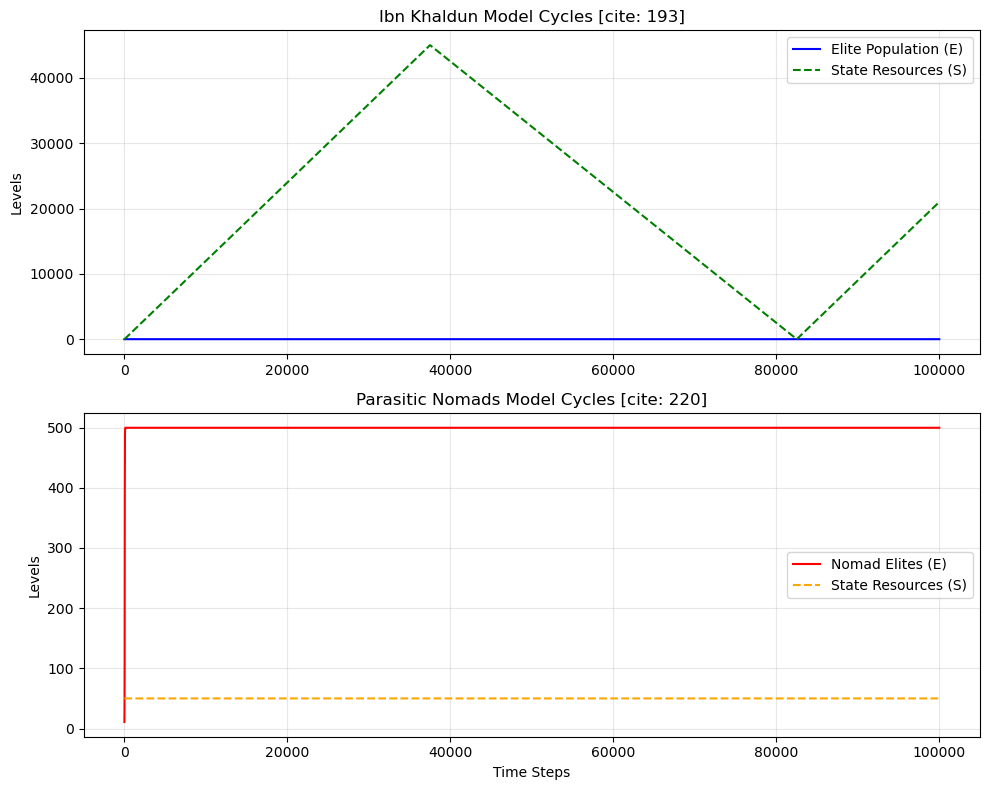

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- MODELS FROM PREVIOUS STEP (Summarized for Plotting) ---

def simulate_khaldun(steps, dt, p):
    """Simulates basic Ibn Khaldun model [cite: 193-204]."""
    E, S, mu_min = p['E0'], 0.1, p['mu_0']
    history = []
    for _ in range(steps):
        # Calculate income mu [cite: 197]
        if p['R'] >= mu_min / (1 - p['gamma']):
            mu = (1 - p['gamma']) * p['R'] / E
        elif mu_min / (1 - p['gamma']) > p['R'] / E >= mu_min:
            mu = mu_min
        else:
            mu = p['R'] / E
            
        r = min(p['chi'] * (mu - p['mu_0']), p['r_max']) # [cite: 199]
        
        # Updates [cite: 201-203]
        E += (r * E) * dt
        S += ((p['R'] - mu * E) - p['alpha'] * E) * dt
        mu_min += p['delta_mu'] * dt
        
        if S < 0: # Reset condition [cite: 204]
            E, S, mu_min = p['E0'], 0.0, p['mu_0']
        history.append((E, S))
    return np.array(history)

def simulate_nomads(steps, dt, p):
    """Simulates Parasitic Nomads model [cite: 220-230]."""
    E, S = p['E0'], p['S0']
    history = []
    for _ in range(steps):
        R = S * (E**2 / (p['h']**2 + E**2)) * p['R_max'] # 
        mu = R / E # [cite: 222]
        r = min(p['chi'] * (mu - p['mu_0']), p['r_max']) # [cite: 224, 225]
        
        E += (r * E) * dt
        S += (0 if mu > p['mu_0'] else -p['alpha']) * dt # [cite: 228]
        
        if S < 0: # Reset condition [cite: 230]
            E, S = p['E0'], p['S0']
        history.append((E, S))
    return np.array(history)

# --- PLOTTING ---

# Parameters for Ibn Khaldun Model
khaldun_params = {
    'R': 100, 'gamma': 0.2, 'mu_0': 5, 'chi': 0.2, 
    'r_max': 0.5, 'alpha': 0.5, 'delta_mu': 0.02, 'E0': 10
}

# Parameters for Nomads Model
nomad_params = {
    'h': 10, 'R_max': 20, 'chi': 0.5, 'mu_0': 2, 
    'r_max': 0.8, 'alpha': 2.0, 'E0': 10, 'S0': 50
}

# Run Simulations
steps, dt = 100000, 0.1
res_k = simulate_khaldun(steps, dt, khaldun_params)
res_n = simulate_nomads(steps, dt, nomad_params)

# Create Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Ibn Khaldun Plot
ax1.plot(res_k[:, 0], label='Elite Population (E)', color='blue')
ax1.plot(res_k[:, 1], label='State Resources (S)', color='green', linestyle='--')
ax1.set_title('Ibn Khaldun Model Cycles [cite: 193]')
ax1.set_ylabel('Levels')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Parasitic Nomads Plot
ax2.plot(res_n[:, 0], label='Nomad Elites (E)', color='red')
ax2.plot(res_n[:, 1], label='State Resources (S)', color='orange', linestyle='--')
ax2.set_title('Parasitic Nomads Model Cycles [cite: 220]')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Levels')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

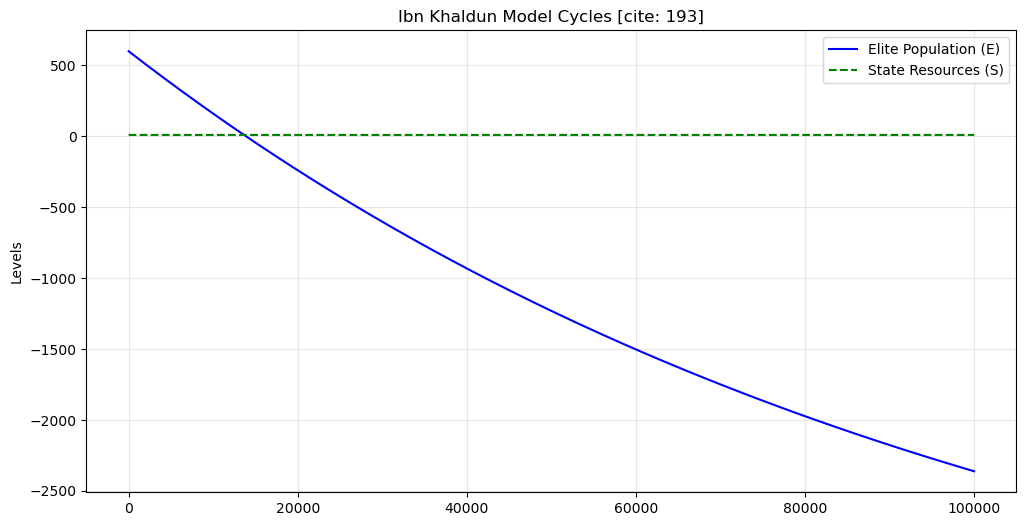

In [17]:
def ibn_khaldun_class_structure(steps, dt, params):
    """
    Implements the Ibn Khaldun model with producer/elite class structure [cite: 205-219].
    """
    # Parameters
    epsilon_0 = params['epsilon_0'] # Max extraction proportion [cite: 207]
    a = params['a']                 # Exploiter coercion area [cite: 207]
    rho_0 = params['rho_0']         # Max food production [cite: 207]
    g = params['g']                 # Productivity decline factor [cite: 207]
    chi_1 = params['chi_1']         # Producer growth coefficient 
    nu_0 = params['nu_0']           # Reference producer income 
    gamma = params['gamma']
    mu_0 = params['mu_0']
    chi = params['chi']
    r_max = params['r_max']
    alpha = params['alpha']
    delta_mu = params['delta_mu']
    E0 = params['E0']
    P0 = params['P0']               # Initial producer population

    E, P = E0, P0
    S, mu_min = 0.0, mu_0
    
    history = []

    for _ in range(steps):
        # Per capita income of commoners (nu) [cite: 207]
        nu = ((1 + (1 - epsilon_0) * a * E) / (1 + a * E)) * rho_0 * (1 - g * P)
        
        # Resources extracted from commoners (R) [cite: 208]
        R = epsilon_0 * (a * E / (1 + a * E)) * rho_0 * (1 - g * P) * P
        
        # Elite income and growth (same logic as basic model) [cite: 210-211]
        if R >= mu_min / (1 - gamma):
            mu = (1 - gamma) * R / E
        elif mu_min / (1 - gamma) > R / E >= mu_min:
            mu = mu_min
        else:
            mu = R / E
            
        r = min(chi * (mu - mu_0), r_max)
        
        # Differential equations [cite: 215-218]
        dP = chi_1 * (nu - nu_0)
        dE = r * E
        dS = (R - mu * E) - alpha * E
        dmu_min = delta_mu
        
        E += dE * dt
        P += dP * dt
        S += dS * dt
        mu_min += dmu_min * dt
        
        # Reset condition [cite: 219]
        if S < 0:
            E, S, mu_min = E0, 0.0, mu_0
            
        history.append((P, E, S))
        
    return np.array(history)
# Parameters for Ibn Khaldun Model with Class Structure
class_structure_params = {
    'epsilon_0': 0.4, 'a': 0.01, 'rho_0': 1.0, 'g': 0.001,
    'chi_1': 0.1, 'nu_0': 5.0,
    'gamma': 0.2, 'mu_0': 5, 'chi': 0.2,
    'r_max': 0.5, 'alpha': 0.5, 'delta_mu': 0.02, 'E0': 10,
    'P0': 600
}
steps, dt = 100000, 0.1
res_k = ibn_khaldun_class_structure(steps, dt, class_structure_params)

# Create Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Ibn Khaldun Plot
ax1.plot(res_k[:, 0], label='Elite Population (E)', color='blue')
ax1.plot(res_k[:, 1], label='State Resources (S)', color='green', linestyle='--')
ax1.set_title('Ibn Khaldun Model Cycles [cite: 193]')
ax1.set_ylabel('Levels')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.show()

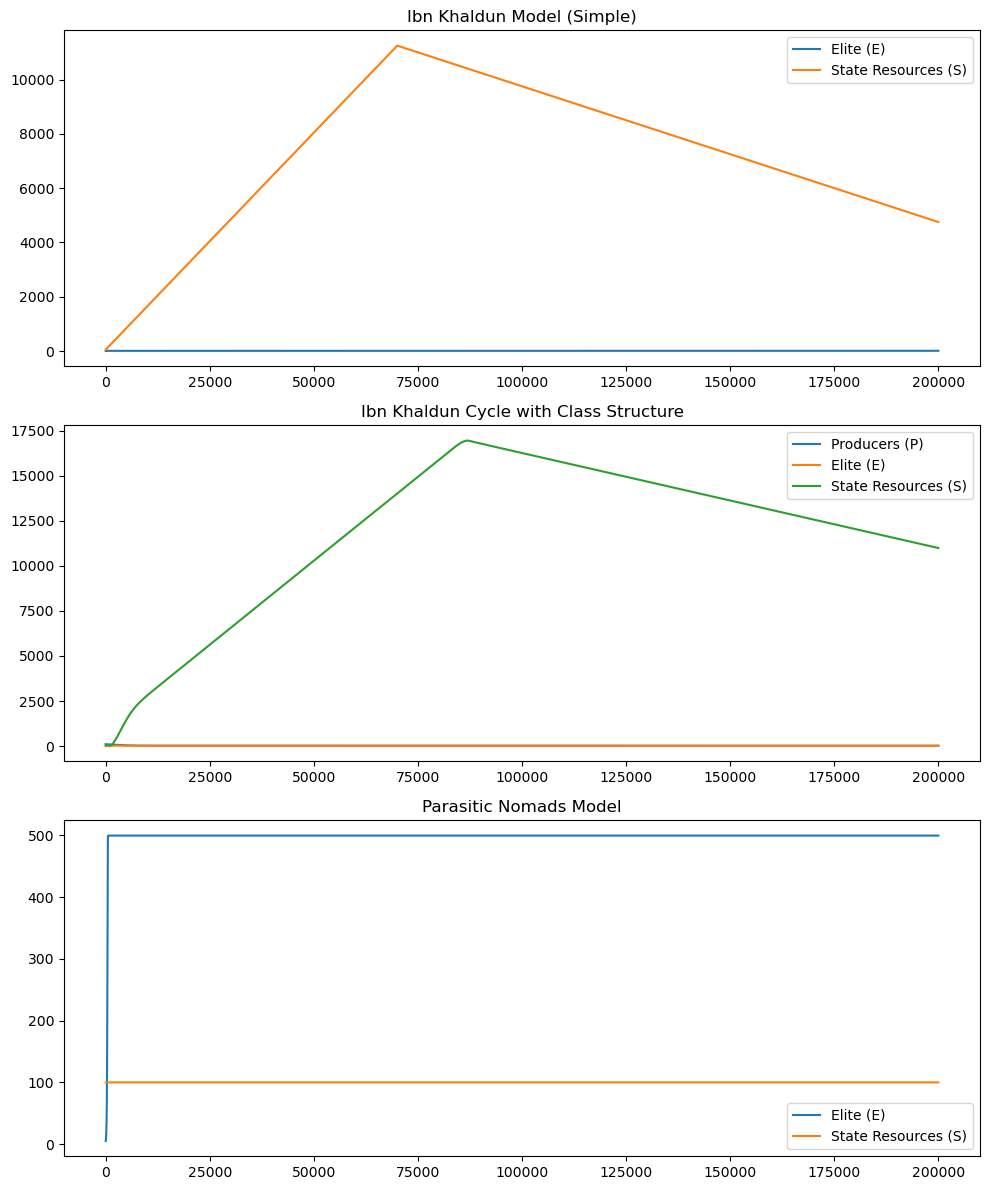

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ibn_khaldun_models(steps=200000, dt=0.1):
    # --- Parameters for Model 1: Ibn Khaldun (Simple) ---
    R = 10.0      # Resources extracted [cite: 195]
    gamma = 0.2   # Tax fraction 
    chi = 0.5     # Elite growth conversion [cite: 199]
    mu_0 = 1.0    # Subsistence income [cite: 199]
    r_max = 0.1   # Max growth rate [cite: 199]
    alpha = 0.05  # State expenditure per elite [cite: 202]
    delta_mu = 0.001 # Minimum income growth [cite: 203]
    
    # Initial conditions
    E, S, mu_min = 2.0, 50.0, 1.0
    E0, S0, mu_min0 = E, S, mu_min
    
    # --- Parameters for Model 2: Ibn Khaldun with Class Structure ---
    # (Reuses some params above)
    epsilon_0 = 0.8
    a_param = 0.1
    rho_0 = 2.0
    g_param = 0.01
    nu_0 = 1.0
    chi_1 = 0.2
    
    P_class, E_class, S_class, mu_min_class = 100.0, 2.0, 50.0, 1.0
    P0_class = P_class
    
    # Data storage
    history_simple = []
    history_class = []

    for t in range(steps):
        # --- SIMPLE MODEL CALCULATION ---
        # 1. Determine Per Capita Elite Income (mu) 
        if R >= mu_min / (1 - gamma):
            mu = (1 - gamma) * R / E
        elif mu_min / (1 - gamma) > R / E >= mu_min:
            mu = mu_min
        else:
            mu = R / E
            
        # 2. Rate of Change [cite: 199, 201-203]
        r = min(chi * (mu - mu_0), r_max)
        dE = r * E
        dS = (R - mu * E) - alpha * E
        d_mu_min = delta_mu
        
        # 3. Update Simple
        E += dE * dt
        S += dS * dt
        mu_min += d_mu_min * dt
        
        # 4. Check Collapse Condition 
        if S < 0:
            E, S, mu_min = E0, 0, mu_0
            
        history_simple.append((E, S))

        # --- CLASS STRUCTURE MODEL CALCULATION ---
        # 1. Producer Income and Extraction [cite: 207]
        nu = ((1 + (1 - epsilon_0) * a_param * E_class) / (1 + a_param * E_class)) * rho_0 * (1 - g_param * P_class)
        R_class = epsilon_0 * (a_param * E_class / (1 + a_param * E_class)) * rho_0 * (1 - g_param * P_class) * P_class
        
        # 2. Elite Income and Growth [cite: 210, 215]
        if R_class >= mu_min_class / (1 - gamma):
            mu_c = (1 - gamma) * R_class / E_class
        elif mu_min_class / (1 - gamma) > R_class / E_class >= mu_min_class:
            mu_c = mu_min_class
        else:
            mu_c = R_class / E_class
            
        r_c = min(chi * (mu_c - mu_0), r_max)
        
        # 3. Derivatives [cite: 215-218]
        dP_class = chi_1 * (nu - nu_0)
        dE_class = r_c * E_class
        dS_class = (R_class - mu_c * E_class) - alpha * E_class
        d_mu_min_class = delta_mu
        
        # 4. Update and Collapse [cite: 219]
        P_class += dP_class * dt
        E_class += dE_class * dt
        S_class += dS_class * dt
        mu_min_class += d_mu_min_class * dt
        
        if S_class < 0:
            E_class, S_class, mu_min_class = E0, 0, mu_0
            
        history_class.append((P_class, E_class, S_class))

    return np.array(history_simple), np.array(history_class)

def simulate_parasitic_nomads(steps=200000, dt=0.1):
    # Parameters [cite: 221-230]
    R_max = 5.0
    h = 10.0
    mu_0 = 1.0
    chi = 0.5
    r_max = 0.1
    alpha = 2.0
    S0, E0 = 100.0, 5.0
    
    E, S = E0, S0
    history = []
    
    for t in range(steps):
        # 1. Extraction [cite: 221-223]
        R = S * (E**2 / (h**2 + E**2)) * R_max
        mu = R / E
        
        # 2. Elite growth [cite: 225-227]
        r = min(chi * (mu - mu_0), r_max)
        dE = r * E
        
        # 3. State resource change [cite: 228-229]
        dS = 0 if mu > mu_0 else -alpha
        
        E += dE * dt
        S += dS * dt
        
        # 4. Reset Condition [cite: 230]
        if S < 0:
            E, S = E0, S0
            
        history.append((E, S))
        
    return np.array(history)

# Execute and Plot
simple_data, class_data = simulate_ibn_khaldun_models()
nomad_data = simulate_parasitic_nomads()

fig, ax = plt.subplots(3, 1, figsize=(10, 12))

ax[0].plot(simple_data[:, 0], label='Elite (E)')
ax[0].plot(simple_data[:, 1], label='State Resources (S)')
ax[0].set_title("Ibn Khaldun Model (Simple)")
ax[0].legend()

ax[1].plot(class_data[:, 0], label='Producers (P)')
ax[1].plot(class_data[:, 1], label='Elite (E)')
ax[1].plot(class_data[:, 2], label='State Resources (S)')
ax[1].set_title("Ibn Khaldun Cycle with Class Structure")
ax[1].legend()

ax[2].plot(nomad_data[:, 0], label='Elite (E)')
ax[2].plot(nomad_data[:, 1], label='State Resources (S)')
ax[2].set_title("Parasitic Nomads Model")
ax[2].legend()

plt.tight_layout()
plt.show()